# Web scraping with Python

Tutorials:


*   https://www.datacamp.com/tutorial/web-scraping-using-python
*   [Google Tutorial](https://colab.research.google.com/github/TannerGilbert/Tutorials/blob/master/Introduction%20to%20Web%20Scraping%20with%20BeautifulSoup/WebScraping_Introduction.ipynb)




## What is Web Scraping?

Web Scraping (also termed Screen Scraping, Web Data Extraction, etc.) is a technique employed to extract large amounts of data from websites whereby the data is extracted and saved to a local file in your computer or to a database in table (spreadsheet) format.

Data displayed by most websites can only be viewed using a web browser. Examples are data litsings at yellow pages directories, real estate sites, social networks, industrial inventory, online shopping sites, contact databases etc. Most websites do not offer the functionality to save a copy of the data which they display to your computer. The only option then is to manually copy and paste the data displayed by the website in your browser to a local file in your computer - a very tedious job which can take many hours or sometimes days to complete.

Web Scraping is the technique of automating this process, so that instead of manually copying the data from websites, the Web Scraping software will perform the same task within a fraction of the time.

A Web Scraping software will interact with websites in the same way as your web browser. But instead of displaying the data served by the website on screen, the Web Scraping software saves the required data from the web page to a local file or database.

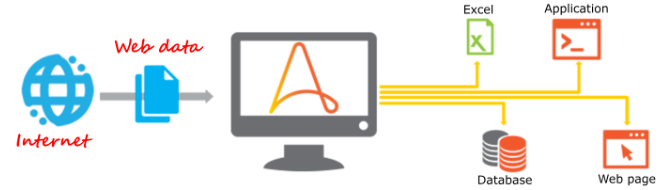

## Python tools for Web Scraping
BeautifulSoup is an incredible Python tool (open library) for pulling out information from a webpage. You can use it to extract tables, lists, paragraph and you can also put filters to extract information from web pages.

You can install it usin pip, for eaxmple:

* `$ pip3 install -U beautifulsoup4`

BeautifulSoup does not fetch the web page for us. That’s why, we will use requests library in combination with the BeautifulSoup library.

Python has several other options for HTML scraping in addition to BeatifulSoup. Here are some others:

* `mechanize`;
* `scrapemark`;
* `scrapy`.

Let's import need libraries:

In [1]:
from bs4 import BeautifulSoup
import requests # This command allows us to fetch URLs

## A few words about HTML tags

### CST 2309

While performing web scarping, we deal with html tags. Thus, we must have good understanding of them. If you already know basics of HTML, you can skip this section. Below is the basic syntax of HTML:

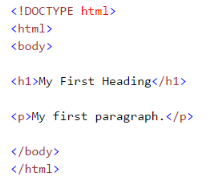


This syntax has various tags as elaborated below:

1. `<!DOCTYPE html>`: HTML documents must start with a type declaration;
2. HTML document is contained between `<html>` and `</html>`;
3. The visible part of the HTML document is between `<body>` and `</body>`;
4. HTML headings are defined with the `<h1>` to `<h6>` tags;
5. HTML paragraphs are defined with the `<p>` tag.

Other useful HTML tags are:

> HTML links are defined with the `<a>` tag, `<a href="http://www.test.com">`This is a link for test.com`</a>`;

> HTML tables are defined with `<table>`, row as `<tr>` and rows are divided into data as `<td>`;



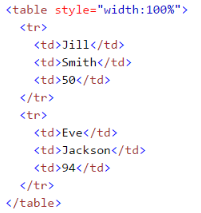

> HTML list starts with `<ul>` (unordered) and `<ol>` (ordered). Each item of list starts with `<li>`;

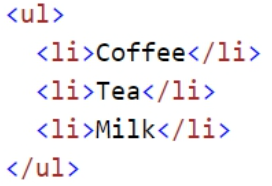

> There are two type of specific HTML tags `<div>` and `<span>` that play role of wrappers for some other tags;

> class and id attributes are identifiers of some HTML tags.

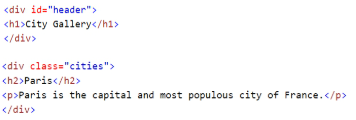

If you are new to this HTML tags, I would also recommend you to refer HTML tutorial from https://www.w3schools.com/html/, for example. This will give you a clear understanding about HTML tags.





# Crawling and Extracting Data from Websites

Beautiful Soup is a library that makes it easy to scrape information from web pages. It sits atop an HTML or XML parser, providing Pythonic idioms for iterating, searching, and modifying the parse tree.

## Searching in HTML: Fetching the webpage title from ESPN.com

Let's start by trying to fetch the headlines from the site ESPN.com.



In [2]:
import pandas # To create a dataframe

# Let's start by fetching the page, and parsing it
url = "http://www.espn.com/"

# Add a user-agent, to pretend to be a browser, not a Python script
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
}

# get the html of that url
response = requests.get(url, headers=headers)

# Parse the web page
espn_soup = BeautifulSoup(response.text, 'html.parser')

Let's start by getting the content of the `<title>` node from the site:

In [3]:
espn_soup


<!DOCTYPE html>

<html class="no-icon-fonts" lang="en">
<head>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="IE=edge,chrome=1" http-equiv="x-ua-compatible"/>
<meta content="initial-scale=1.0, maximum-scale=1.0, user-scalable=no" name="viewport"/>
<meta content="origin-when-cross-origin" name="referrer"/>
<link href="https://www.espn.com" rel="canonical"/>
<title>ESPN - Serving Sports Fans. Anytime. Anywhere.</title>
<meta content="Visit ESPN for live scores, highlights and sports news. Stream exclusive games on ESPN and play fantasy sports." name="description">
<link href="/manifest.json" rel="manifest"/>
<meta content="116656161708917" property="fb:app_id">
<meta content="ESPN.com" property="og:site_name"/>
<meta content="https://www.espn.com" property="og:url"/>
<meta content="ESPN - Serving Sports Fans. Anytime. Anywhere." property="og:title"/>
<meta content="Visit ESPN for live scores, highlights and sports news. Stream exclusive games on ESPN

In [4]:
# This code finds the tag <title> in the HTML of ESPN.com
results = espn_soup.find('title')
results

<title>ESPN - Serving Sports Fans. Anytime. Anywhere.</title>

In [5]:
# Now let's get the text of that node
results = espn_soup.find('title').string
results

'ESPN - Serving Sports Fans. Anytime. Anywhere.'

### Exercise

* Connect to the CityTech website, and fetch the title of the page

In [6]:
# your code here

# Let's start by fetching the page, and parsing it
url = "https://www.citytech.cuny.edu/"

# Add a user-agent, to pretend to be a browser, not a Python script
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# get the html of that url
response = requests.get(url, headers=headers)

# Parse the web page
cuny_soup = BeautifulSoup(response.text, 'html.parser')

cuny_soup.find('title')

<title>City Tech - New York City College of Technology</title>

In [7]:
# @title Solution
cuny_url = 'https://www.citytech.cuny.edu/'
cuny_html = requests.get(cuny_url).text
cuny_soup = BeautifulSoup(cuny_html, 'html.parser')

title = cuny_soup.find('title').string
title

'City Tech - New York City College of Technology'

## Searching for elements of interest in the web page

Now, let's say that we are looking to retrieve *multiple* elements from a web page. For that we can use the `soup.find_all` command.

For example, to find all the `<a ...> ... </a>` tags in the returned html, which store the links in the page, we issue the command:

In [8]:
# Get all the <a ...> ... </a> elements, which are the links on the page
links = espn_soup.find_all("a")
len(links)

197

In [9]:
# Let's pick now one of the many links
lnk = links[80]
type(lnk.string)

NoneType

In [10]:
links[191]

<a href="http://www.nielsen.com/digitalprivacy">About Nielsen Measurement</a>

 To get parts of the html element that we need, we can use the `get` method (e.g., to get the `href` attribute) and the `text` method (to get the text within the `<a>...</a>` tag.

In [11]:
lnk.get("href")

'http://xgames.espn.com'

In [12]:
lnk.text

'\n\n\nX Games\n\n'

In [13]:
# The strip() removes blank spaces before and after the text
lnk.text.strip()

'X Games'

Let's put everything together

In [14]:
links = espn_soup.find_all("a")

# Iterates over all the links (this means all the nodes
# that matched the //a XPath query) and prints the content
# of the attribute href and the text for that node
for link in links:
    print("==================================")
    print(link.get("href"), "==>", link.text.strip())

# ==> Menu
/ ==> ESPN
/where-to-watch ==> 
# ==> 
# ==> scores
/nfl/ ==> NFL
/nba/ ==> NBA
/mlb/ ==> MLB
/college-football/ ==> NCAAF
/nhl/ ==> NHL
/soccer/ ==> Soccer
/wnba/ ==> WNBA
# ==> More Sports
/boxing/ ==> Boxing
/college-sports/ ==> NCAA
https://www.espncricinfo.com/ ==> Cricket
/f1/ ==> F1
/gaming/ ==> Gaming
/golf/ ==> Golf
/horse-racing/ ==> Horse
/little-league-world-series/ ==> LLWS
/mma/ ==> MMA
/racing/nascar/ ==> NASCAR
/nll/ ==> NLL
/nba-g-league/ ==> NBA G League
/nba-summer-league/ ==> NBA Summer League
/mens-college-basketball/ ==> NCAAM
/womens-college-basketball/ ==> NCAAW
/soccer/league/_/name/USA.NWSL ==> NWSL
/olympics/ ==> Olympics
/pll/ ==> PLL
/professional-wrestling/ ==> Professional Wrestling
/racing/ ==> Racing
/college-sports/basketball/recruiting/ ==> RN BB
/college-sports/football/recruiting/ ==> RN FB
/rugby/ ==> Rugby
/sports-betting/ ==> Sports Betting
/tennis/ ==> Tennis
/tgl/ ==> TGL
/ufl/ ==> UFL
/wwe/ ==> WWE
# ==> Editions
https://www.espn.co

Now, let's revisit the _list comprehension_ approach that we discussed in the Python Primer session, for quickly constructing lists:

In [15]:
# List comprehension approach
urls = [lnk.get("href") for lnk in espn_soup.find_all('a')]
urls

# Verbose version instead of the link comprehension approach
urls = []
for lnk in espn_soup.find_all('a'):
  urls.append(lnk.get("href"))


In [16]:
# You can safely skip the code below.
# A bit fancier, adding a prefix of http://www.espn.com/ when the URL is
# relative and does not include the domain
domain = "http://www.espn.com/"
urls = [
    lnk.get("href") if lnk.get("href").startswith("http") else domain + lnk.get("href")
    for lnk in espn_soup.find_all('a') if lnk.get("href")
]
urls

['http://www.espn.com/#',
 'http://www.espn.com//',
 'http://www.espn.com//where-to-watch',
 'http://www.espn.com/#',
 'http://www.espn.com/#',
 'http://www.espn.com//nfl/',
 'http://www.espn.com//nba/',
 'http://www.espn.com//mlb/',
 'http://www.espn.com//college-football/',
 'http://www.espn.com//nhl/',
 'http://www.espn.com//soccer/',
 'http://www.espn.com//wnba/',
 'http://www.espn.com/#',
 'http://www.espn.com//boxing/',
 'http://www.espn.com//college-sports/',
 'https://www.espncricinfo.com/',
 'http://www.espn.com//f1/',
 'http://www.espn.com//gaming/',
 'http://www.espn.com//golf/',
 'http://www.espn.com//horse-racing/',
 'http://www.espn.com//little-league-world-series/',
 'http://www.espn.com//mma/',
 'http://www.espn.com//racing/nascar/',
 'http://www.espn.com//nll/',
 'http://www.espn.com//nba-g-league/',
 'http://www.espn.com//nba-summer-league/',
 'http://www.espn.com//mens-college-basketball/',
 'http://www.espn.com//womens-college-basketball/',
 'http://www.espn.com//so

### Exercise

Use a list compresension approach, to get the text_content of all the URLs in the page.

In [17]:
# your code here
requests.get(urls[4]).text

'<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN" "http://www.w3.org/TR/html4/loose.dtd">\n<HTML><HEAD><META HTTP-EQUIV="Content-Type" CONTENT="text/html; charset=iso-8859-1">\n<TITLE>ERROR: The request could not be satisfied</TITLE>\n</HEAD><BODY>\n<H1>403 ERROR</H1>\n<H2>The request could not be satisfied.</H2>\n<HR noshade size="1px">\nRequest blocked.\nWe can\'t connect to the server for this app or website at this time. There might be too much traffic or a configuration error. Try again later, or contact the app or website owner.\n<BR clear="all">\nIf you provide content to customers through CloudFront, you can find steps to troubleshoot and help prevent this error by reviewing the CloudFront documentation.\n<BR clear="all">\n<HR noshade size="1px">\n<PRE>\nGenerated by cloudfront (CloudFront)\nRequest ID: BlaHdgpa9jUP5yEhIQ69yqsKjLddpvFA4YhUxdaoqV-HP8j0n9PqlA==\n</PRE>\n<ADDRESS>\n</ADDRESS>\n</BODY></HTML>'

And now create a list where we put together text content and the URL for each link

In [18]:
# your code here

#### Solution

In [19]:
text = [lnk.text.strip() for lnk in espn_soup.find_all("a")]
text

['Menu',
 'ESPN',
 '',
 '',
 'scores',
 'NFL',
 'NBA',
 'MLB',
 'NCAAF',
 'NHL',
 'Soccer',
 'WNBA',
 'More Sports',
 'Boxing',
 'NCAA',
 'Cricket',
 'F1',
 'Gaming',
 'Golf',
 'Horse',
 'LLWS',
 'MMA',
 'NASCAR',
 'NLL',
 'NBA G League',
 'NBA Summer League',
 'NCAAM',
 'NCAAW',
 'NWSL',
 'Olympics',
 'PLL',
 'Professional Wrestling',
 'Racing',
 'RN BB',
 'RN FB',
 'Rugby',
 'Sports Betting',
 'Tennis',
 'TGL',
 'UFL',
 'WWE',
 'Editions',
 'Where to Watch',
 'Fantasy',
 'Bet',
 'Watch',
 'Sign Up Now',
 'Watch Now',
 'Subscribe Now',
 'MNF: Eagles vs. Packers',
 'MNF with Peyton & Eli',
 "Live: NCAA Men's Basketball",
 "Live: NCAA Women's Basketball",
 'NHL Power Play',
 'NFL PrimeTime',
 "Peyton's Places: New Episode",
 'SportsCenter For You',
 'UFC 322: Della Maddalena vs. Makhachev (PPV)',
 'College Football Playoff',
 'College Football Schedule',
 'NFL Schedule',
 "Men's Hoops Schedule",
 "Women's Hoops Schedule",
 'NBA Cup',
 'Fantasy Football',
 'Where To Watch',
 "Today's Top

In [20]:
# Do not include empty pieces of text
text = [lnk.text.strip() for lnk in espn_soup.find_all("a") if len(lnk.text.strip())>0]
text

['Menu',
 'ESPN',
 'scores',
 'NFL',
 'NBA',
 'MLB',
 'NCAAF',
 'NHL',
 'Soccer',
 'WNBA',
 'More Sports',
 'Boxing',
 'NCAA',
 'Cricket',
 'F1',
 'Gaming',
 'Golf',
 'Horse',
 'LLWS',
 'MMA',
 'NASCAR',
 'NLL',
 'NBA G League',
 'NBA Summer League',
 'NCAAM',
 'NCAAW',
 'NWSL',
 'Olympics',
 'PLL',
 'Professional Wrestling',
 'Racing',
 'RN BB',
 'RN FB',
 'Rugby',
 'Sports Betting',
 'Tennis',
 'TGL',
 'UFL',
 'WWE',
 'Editions',
 'Where to Watch',
 'Fantasy',
 'Bet',
 'Watch',
 'Sign Up Now',
 'Watch Now',
 'Subscribe Now',
 'MNF: Eagles vs. Packers',
 'MNF with Peyton & Eli',
 "Live: NCAA Men's Basketball",
 "Live: NCAA Women's Basketball",
 'NHL Power Play',
 'NFL PrimeTime',
 "Peyton's Places: New Episode",
 'SportsCenter For You',
 'UFC 322: Della Maddalena vs. Makhachev (PPV)',
 'College Football Playoff',
 'College Football Schedule',
 'NFL Schedule',
 "Men's Hoops Schedule",
 "Women's Hoops Schedule",
 'NBA Cup',
 'Fantasy Football',
 'Where To Watch',
 "Today's Top Odds",
 '

In [21]:
# Creating a list of tuples where we put together href and text for each link
list_tuples = [(lnk.get("href"), lnk.text.strip()) for lnk in espn_soup.find_all("a")]
list_tuples

[('#', 'Menu'),
 ('/', 'ESPN'),
 ('/where-to-watch', ''),
 ('#', ''),
 ('#', 'scores'),
 ('/nfl/', 'NFL'),
 ('/nba/', 'NBA'),
 ('/mlb/', 'MLB'),
 ('/college-football/', 'NCAAF'),
 ('/nhl/', 'NHL'),
 ('/soccer/', 'Soccer'),
 ('/wnba/', 'WNBA'),
 ('#', 'More Sports'),
 ('/boxing/', 'Boxing'),
 ('/college-sports/', 'NCAA'),
 ('https://www.espncricinfo.com/', 'Cricket'),
 ('/f1/', 'F1'),
 ('/gaming/', 'Gaming'),
 ('/golf/', 'Golf'),
 ('/horse-racing/', 'Horse'),
 ('/little-league-world-series/', 'LLWS'),
 ('/mma/', 'MMA'),
 ('/racing/nascar/', 'NASCAR'),
 ('/nll/', 'NLL'),
 ('/nba-g-league/', 'NBA G League'),
 ('/nba-summer-league/', 'NBA Summer League'),
 ('/mens-college-basketball/', 'NCAAM'),
 ('/womens-college-basketball/', 'NCAAW'),
 ('/soccer/league/_/name/USA.NWSL', 'NWSL'),
 ('/olympics/', 'Olympics'),
 ('/pll/', 'PLL'),
 ('/professional-wrestling/', 'Professional Wrestling'),
 ('/racing/', 'Racing'),
 ('/college-sports/basketball/recruiting/', 'RN BB'),
 ('/college-sports/football

In [22]:
# Creating a list of dictionaries with the text and URL for each link
list_dicts = [{"URL": lnk.get("href"), "Text": lnk.text.strip()} for lnk in espn_soup.find_all("a")]
list_dicts

[{'URL': '#', 'Text': 'Menu'},
 {'URL': '/', 'Text': 'ESPN'},
 {'URL': '/where-to-watch', 'Text': ''},
 {'URL': '#', 'Text': ''},
 {'URL': '#', 'Text': 'scores'},
 {'URL': '/nfl/', 'Text': 'NFL'},
 {'URL': '/nba/', 'Text': 'NBA'},
 {'URL': '/mlb/', 'Text': 'MLB'},
 {'URL': '/college-football/', 'Text': 'NCAAF'},
 {'URL': '/nhl/', 'Text': 'NHL'},
 {'URL': '/soccer/', 'Text': 'Soccer'},
 {'URL': '/wnba/', 'Text': 'WNBA'},
 {'URL': '#', 'Text': 'More Sports'},
 {'URL': '/boxing/', 'Text': 'Boxing'},
 {'URL': '/college-sports/', 'Text': 'NCAA'},
 {'URL': 'https://www.espncricinfo.com/', 'Text': 'Cricket'},
 {'URL': '/f1/', 'Text': 'F1'},
 {'URL': '/gaming/', 'Text': 'Gaming'},
 {'URL': '/golf/', 'Text': 'Golf'},
 {'URL': '/horse-racing/', 'Text': 'Horse'},
 {'URL': '/little-league-world-series/', 'Text': 'LLWS'},
 {'URL': '/mma/', 'Text': 'MMA'},
 {'URL': '/racing/nascar/', 'Text': 'NASCAR'},
 {'URL': '/nll/', 'Text': 'NLL'},
 {'URL': '/nba-g-league/', 'Text': 'NBA G League'},
 {'URL': '/n

In [23]:
import pandas as pd
pd.DataFrame(list_dicts)

,URL,Text
0,#,Menu
1,/,ESPN
2,/where-to-watch,
3,#,
4,#,scores
...,...,...
192,https://privacy.thewaltdisneycompany.com/en/dn...,Do Not Sell or Share My Personal Information
193,https://www.espn.com/espn/news/story?page=cont...,Contact Us
194,https://www.disneyadvertising.com/,Disney Ad Sales Site
195,https://jobs.disneycareers.com/espn,Work for ESPN


### More Advanced Example: Get the list of headlines from ESPN


Now, let's examine how we can get the data from the website. The key is to understand the structure of the HTML, where the data that we need is stored, and how to fetch the elements. Then, using the appropriate XPath queries, we will get what we want.

Let's start by fetching the page, and parsing it

In [24]:
# Let's start by fetching the page, and parsing it
url = "http://www.espn.com/"

# Add a user-agent, to pretend to be a browser, not a Python script
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# get the html of that url
response = requests.get(url, headers=headers)

# Parse the web page
espn_soup = BeautifulSoup(response.text, 'html.parser')

By using the `"Right-Click > Inspect"` option of Chrome,
we right click on the headlines and select `"Inspect"`.
This opens the source code.
There we see that all under a `<div class="headlineStack">` tag.

In [25]:
headlineNode = espn_soup.find_all('div', class_='headlineStack')

The result of that operation is a list with 8 elements.

In [26]:
type(headlineNode)

bs4.element.ResultSet

In [27]:
len(headlineNode)

5

Each headline is under a  `<li><a href="...."></a>` tag.
So, we get all the `<li><a ...>` tags within the `<div class="headlineStack">`
(which is stored in the "`headlineNode`" variable)

In [28]:
headlines = headlineNode[0].find_all('li')
headlines = [li.find('a') for li in headlines]
len(headlines)

9

In [29]:
headlines[0]

<a class="" data-mptype="headline" href="/nfl/story/_/id/46917837/rob-gronkowski-sign-one-day-contract-retire-patriot" name="&amp;lpos=fp:feed:xx:coll:headlines:1">Gronk to fulfill late friend's wish, retire as Patriot</a>

Now, we have the nodes with the conent in the headlines variable.
We extract the text and the URL.

In [30]:
data = [{"Title": a.text, "URL": a.get("href")} for a in headlines]
data

[{'Title': "Gronk to fulfill late friend's wish, retire as Patriot",
  'URL': '/nfl/story/_/id/46917837/rob-gronkowski-sign-one-day-contract-retire-patriot'},
 {'Title': "Baylor, USC jump into top 10 of women's AP poll",
  'URL': '/womens-college-basketball/story/_/id/46918181/baylor-usc-enter-top-10-women-ap-top-25-uconn-no-1'},
 {'Title': 'Rodgers offers blunt self-assessment after SNF dud',
  'URL': '/nfl/story/_/id/46914310/aaron-rodgers-struggles-steelers-loss-chargers-says-got-play-better'},
 {'Title': 'Report: Kelly rejected LSU buyouts, seeks $54M',
  'URL': '/college-football/story/_/id/46915913/ex-lsu-coach-brian-kelly-rejected-2-settlement-offers'},
 {'Title': 'Payne suspended 1 game for St. Brown punch',
  'URL': '/nfl/story/_/id/46917039/commanders-daron-payne-suspended-punching-amon-ra-st-brown'},
 {'Title': 'Japanese pitcher Imai begins process to join MLB',
  'URL': '/mlb/story/_/id/46915520/tatsuya-imai-become-next-japanese-pitcher-move-mlb'},
 {'Title': 'Legendary NBA

And let's create our dataframe, so that we can have a better view

In [31]:
dataframe = pandas.DataFrame(data)
dataframe

,Title,URL
0,"Gronk to fulfill late friend's wish, retire as...",/nfl/story/_/id/46917837/rob-gronkowski-sign-o...
1,"Baylor, USC jump into top 10 of women's AP poll",/womens-college-basketball/story/_/id/46918181...
2,Rodgers offers blunt self-assessment after SNF...,/nfl/story/_/id/46914310/aaron-rodgers-struggl...
3,"Report: Kelly rejected LSU buyouts, seeks $54M",/college-football/story/_/id/46915913/ex-lsu-c...
4,Payne suspended 1 game for St. Brown punch,/nfl/story/_/id/46917039/commanders-daron-payn...
5,Japanese pitcher Imai begins process to join MLB,/mlb/story/_/id/46915520/tatsuya-imai-become-n...
6,"Legendary NBA player, coach Wilkens dies at 88",/nba/story/_/id/46910949/legendary-nba-player-...
7,"Guardians' Clase, Ortiz indicted for pitch rig...",/mlb/story/_/id/46906636/guardians-emmanuel-cl...
8,🏈 College Football Power Ranks: 3 newcomers,/college-football/story/_/id/46907483/2025-col...


#### Of course, there are always more than one way to skin a cat...

Alternatively, if we did not want to restrict ourselves to just the first headline box, we could write an alternative query, to get back all the headlines, that appear with the pattern of appearing under a `<div class=headlineStack>` and then under a `<li>` tag and then under an `<a>` tag

In [32]:
headlines = espn_soup.select('div.headlineStack li a')
data = [{"Title": a.text, "URL": a.get("href")} for a in headlines if a.has_attr('href')]
df = pandas.DataFrame(data)
df

,Title,URL
0,"Gronk to fulfill late friend's wish, retire as...",/nfl/story/_/id/46917837/rob-gronkowski-sign-o...
1,"Baylor, USC jump into top 10 of women's AP poll",/womens-college-basketball/story/_/id/46918181...
2,Rodgers offers blunt self-assessment after SNF...,/nfl/story/_/id/46914310/aaron-rodgers-struggl...
3,"Report: Kelly rejected LSU buyouts, seeks $54M",/college-football/story/_/id/46915913/ex-lsu-c...
4,Payne suspended 1 game for St. Brown punch,/nfl/story/_/id/46917039/commanders-daron-payn...
5,Japanese pitcher Imai begins process to join MLB,/mlb/story/_/id/46915520/tatsuya-imai-become-n...
6,"Legendary NBA player, coach Wilkens dies at 88",/nba/story/_/id/46910949/legendary-nba-player-...
7,"Guardians' Clase, Ortiz indicted for pitch rig...",/mlb/story/_/id/46906636/guardians-emmanuel-cl...
8,🏈 College Football Power Ranks: 3 newcomers,/college-football/story/_/id/46907483/2025-col...
9,⬆⬇ Standings,https://www.espn.com/nfl/standings


In [33]:
headlines = espn_soup.find_all('a', {'data-mptype': 'headline'})
data = [{"Title": a.text, "URL": a.get("href")} for a in headlines]
df = pandas.DataFrame(data)
df

,Title,URL
0,"Gronk to fulfill late friend's wish, retire as...",/nfl/story/_/id/46917837/rob-gronkowski-sign-o...
1,"Baylor, USC jump into top 10 of women's AP poll",/womens-college-basketball/story/_/id/46918181...
2,Rodgers offers blunt self-assessment after SNF...,/nfl/story/_/id/46914310/aaron-rodgers-struggl...
3,"Report: Kelly rejected LSU buyouts, seeks $54M",/college-football/story/_/id/46915913/ex-lsu-c...
4,Payne suspended 1 game for St. Brown punch,/nfl/story/_/id/46917039/commanders-daron-payn...
5,Japanese pitcher Imai begins process to join MLB,/mlb/story/_/id/46915520/tatsuya-imai-become-n...
6,"Legendary NBA player, coach Wilkens dies at 88",/nba/story/_/id/46910949/legendary-nba-player-...
7,"Guardians' Clase, Ortiz indicted for pitch rig...",/mlb/story/_/id/46906636/guardians-emmanuel-cl...
8,🏈 College Football Power Ranks: 3 newcomers,/college-football/story/_/id/46907483/2025-col...
9,⬆⬇ Standings,https://www.espn.com/nfl/standings
